## Creating Lo-Fi data for small/large amplitude oscillatory shear (S/LAOS) rheometry
In this notebook, the synthetic generation of Lo-Fi data is introduced based on the given Hi-Fi data. This is a more intricate one as we need to introduce some form of physics to generate the Lo-Fi data.

First of all, we need to extract the time shift for each S/LAOS test. Note that the given data is in sheets. For each sheet, we need to extract the shifted time, maxietam strain, angular frequency, stress, strain, and strain rate, respectively, by calling the `extractor()` function.


### Importing dependencies

In [1]:
# Standard library
import os
import sys
from time import time

# Numerical / scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import odeint

# Scikit-learn core utilities
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.compose import TransformedTargetRegressor

# Scikit-learn models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor, RegressorChain

# Gaussian Processes
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

# XGBoost
import xgboost as xgb


In [2]:
np.set_printoptions(suppress=True)
file = pd.ExcelFile(r"/home/alanh/projects/PunLab/mfnn/experiments/Pigs_NegCon/combined_pig_negcon.xlsx")

df = pd.read_excel(file, sheet_name=None)
data = [[k,v] for k,v in df.items()]
data.pop(23)  # Data incorrect in this sheet
t_train, g_train, w_train = np.array([]), np.array([]), np.array([])
s_train = np.array([])

def pos_finder(vector):
    vector = np.array(vector)
    for i in range(len(vector) - 1):
        if vector[i] < 0 and vector[i + 1] >= 0:
            return i + 1
    return np.argmin(np.abs(vector))    # ERROR: Not finding crossings?
    
def extractor(i):
    data[i][1] = data[i][1].dropna()
    print(data[i][0])
    
    # Handling the time shift
    ind = pos_finder(data[i][1]['Strain'])
    print("Start Index: ", ind)
    t0 = data[i][1]['Step time'].iloc[ind]
    ymax = data[i][1]['Stress'].iloc[ind]
    
    # Column extraction 
    St = data[i][1]['Strain']
    SR = data[i][1]['Shear rate']
    Time = data[i][1]['Step time']
    w = data[i][1]['Angular frequency']
    G0 = data[i][1]['Oscillation strain']
    Stress = data[i][1]['Stress']
    Time_adj = Time - t0
    Time_adj = Time_adj
    return Time_adj, G0, w, Stress, St, SR

### Extracting $\tau$ and $\eta$
Then, you need to run the following cell for all sheets in `Data_HF_SAOS_raw.xlsx`. For each sheet, we fit a single-mode Maxwell VE model and extract $\tau$ and $\eta$ as a function of $\gamma_0$, $\omega$, and $t$. Note that we are using the `odeint` package, which is an ODE solver. Similar to other ODE solvers, we need initial condition (`y0`), `initial_guess`, and `bounds`. For each sheet, an appropriate `y0` is needed. For this particular sheet, `y0` is 90 Pa.

For this sheet, $\tau$ and $\eta$ are 0.16183 and0.14525, respectively. We do the same thing for all stress curves to obtain the following table:

In [3]:
# # Initialize lists to store the results from all sheets
# Y_fit_list = []
# X_fit_list = []
# y0_fit_list = []

# # Define the fitting function based on the analytical solution
# def maxwell_stress(t, eta, tau, y0, g0, omega, tmax, wmax):
#     """
#     Calculates the analytical stress response of a Maxwell element 
#     to sinusoidal strain: g(t) = g0 * sin(W*t).
    
#     Equation: sigma(t) = sigma_ss(t) + C * exp(-t/tau)
#     """
#     # Effective frequency (combining normalization factors)
#     W = omega * tmax * wmax
    
#     # Avoid division by zero if tau is extremely small
#     if tau < 1e-12: 
#         tau = 1e-12

#     # Pre-compute recurring terms
#     WT = W * tau
#     denom = 1 + WT**2
    
#     # Calculate Steady State Components
#     # G'' component (Loss/Viscous) - in phase with strain rate (cos)
#     sigma_loss = (eta * g0 * W) / denom
    
#     # G' component (Storage/Elastic) - in phase with strain (sin)
#     sigma_storage = (eta * g0 * W * WT) / denom
    
#     # Calculate Transient Component
#     # At t=0, sin(0)=0, cos(0)=1. 
#     # Therefore: sigma(0) = sigma_loss + C
#     # C = y0 - sigma_loss
#     C = y0 - sigma_loss
    
#     # Full Stress Equation
#     stress = (sigma_loss * np.cos(W * t) + 
#               sigma_storage * np.sin(W * t) + 
#               C * np.exp(-t / tau))
              
#     return stress

# # Loop over all sheets
# for i in range(len(data)):
#     print(f"--- Processing Sheet {i}: {data[i][0]} ---")
    
#     # Extract data for this specific sheet
#     t_train, g_train, w_train, s_train, st_train, sr_train = extractor(i)
    
#     # Normalization settings: ONLY NEEDED FOR MLP Regressor
#     Norm = False
#     if Norm:
#         tmax = max(t_train)
#         gmax = max(g_train)
#         wmax = max(w_train)
#         smax = max(s_train)
#         t_train, g_train, w_train, s_train = t_train/tmax, g_train/gmax, w_train/wmax, s_train/smax
#     else:
#         tmax = 1.
#         gmax = 1.
#         wmax = 1.
#         smax = 1.

#     # Get relevant maxwell variables
#     assert len(np.unique(g_train)) == 1
#     assert len(np.unique(w_train)) == 1
#     g0 = np.unique(g_train)[0]
#     omega = np.unique(w_train)[0]
#     y0 = s_train.iloc[0] if hasattr(s_train, 'iloc') else s_train[0]
    
#     # Setup fitting vectors
#     t = t_train
#     y = s_train
#     g = g0 * np.sin(omega * t_train * tmax * wmax)  # Theoretical strain ONLY for plotting, should be fine to use st_train with SPP

#     # Wrapper to freeze extra variables
#     fit_wrapper = lambda t_val, eta_val, tau_val: maxwell_stress(
#         t_val, eta_val, tau_val,
#         y0, g0, omega, tmax, wmax
#     )

#     # Make initial guess and bounds
#     stress_amp = (np.max(s_train) - np.min(s_train)) / 2.0
#     eta_guess = stress_amp / (g0 * omega)
#     tau_guess = 1.0 / omega
#     initial_guess = [eta_guess, tau_guess]
    
#     # Perform the Fit
#     bounds = ([0.0, 0.0], [np.inf, np.inf])

    
#     try:
#         fit_params, covariance = curve_fit(fit_wrapper, t, y,
#                                            p0=initial_guess,
#                                            bounds=bounds,
#                                            method='trf',
#                                            maxfev=5000)
#         eta_fit, tau_fit = fit_params
#     except RuntimeError:
#         print(f"Fit failed for sheet {i}. Using zeros.")
#         eta_fit, tau_fit = 0.0, 0.0

#     # Append results
#     # Y_fit stores [eta, tau]
#     Y_fit_list.append([eta_fit, tau_fit])
#     # X_fit stores [omega, g0]
#     X_fit_list.append([omega, g0])
#     # y0_fit stores the initial stress
#     y0_fit_list.append(y0)

#     # Plot
#     y_predicted = maxwell_stress(t, eta_fit, tau_fit, y0, g0, omega, tmax, wmax)
    
#     plt.figure(figsize=(6, 4))
#     plt.title(f"Sheet {i} | w={omega:.6f}, g0={g0:.6f}")
#     plt.scatter(g, y, label='Reference (Hi-Fi)', s=2, color='k', alpha=0.3)
#     plt.plot(g, y_predicted, '-', label=f'Maxwell Fit\n$\eta$={eta_fit:.3f}, $\\tau$={tau_fit:.3f}', linewidth=2, color='tab:red')
#     plt.xlabel('Strain')
#     plt.ylabel('Stress')
#     plt.legend()
#     plt.show()

# # --- Convert lists to numpy arrays for the next steps ---
# Y_fit = np.array(Y_fit_list)
# X_fit = np.array(X_fit_list)
# y0_fit = np.array(y0_fit_list)

# print("\nY_fit (eta, tau):")
# print(repr(Y_fit))
# print("\nX_fit (omega, g0):")
# print(repr(X_fit))
# print("\ny0_fit (initial stress):")
# print(repr(y0_fit))

--- Processing Sheet 0: 0.628rad - 7.19e-05 ---
0.628rad - 7.19e-05
Start Index:  0


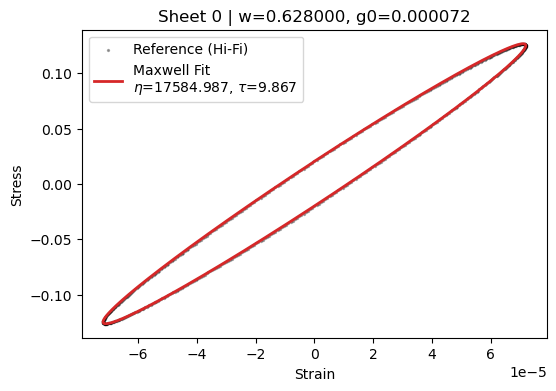

--- Processing Sheet 1: 0.628rad - 0.0002555 ---
0.628rad - 0.0002555
Start Index:  0


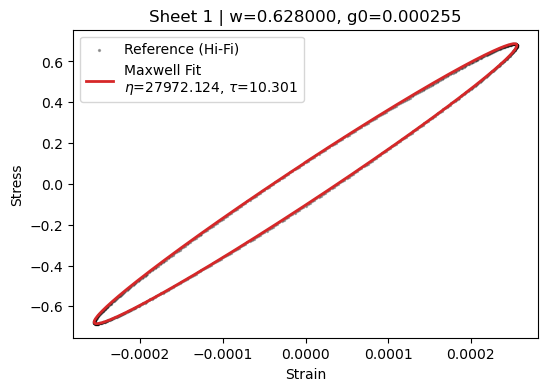

--- Processing Sheet 2: 0.628rad - 0.0008726 ---
0.628rad - 0.0008726
Start Index:  0


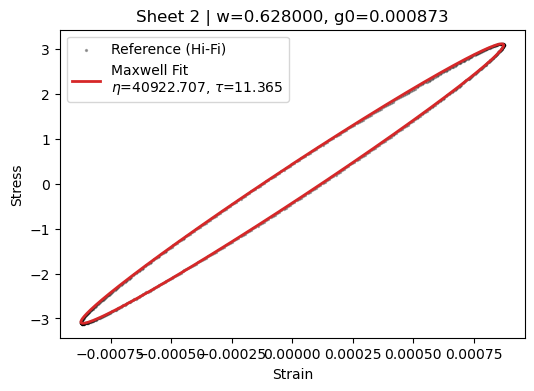

--- Processing Sheet 3: 0.628rad - 0.0027413 ---
0.628rad - 0.0027413
Start Index:  0


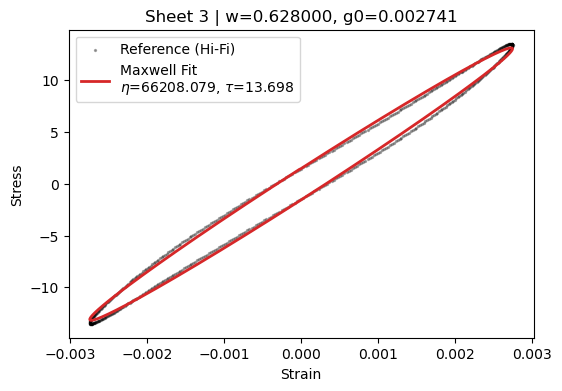

--- Processing Sheet 4: 0.628rad - 0.0073965 ---
0.628rad - 0.0073965
Start Index:  0


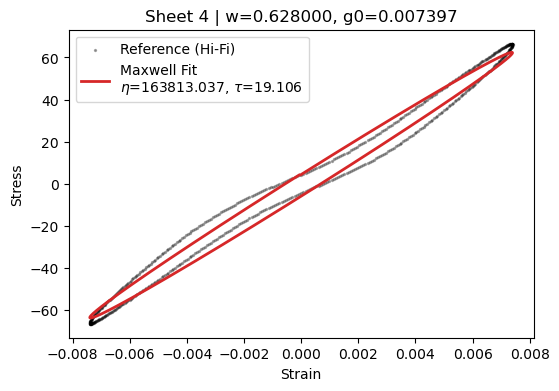

--- Processing Sheet 5: 0.628rad - 0.0235937 ---
0.628rad - 0.0235937
Start Index:  0


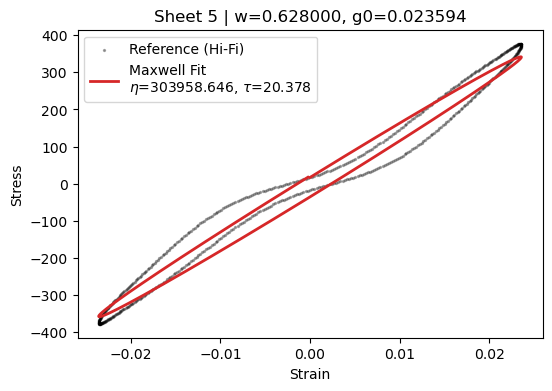

--- Processing Sheet 6: 0.628rad - 7.46e-05 ---
0.628rad - 7.46e-05
Start Index:  0


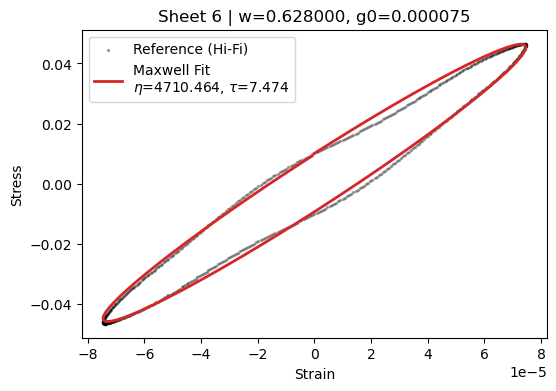

--- Processing Sheet 7: 0.628rad - 0.0002212 ---
0.628rad - 0.0002212
Start Index:  0


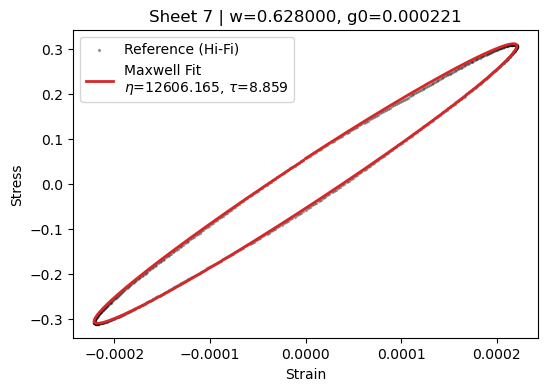

--- Processing Sheet 8: 0.628rad - 0.0007927 ---
0.628rad - 0.0007927
Start Index:  0


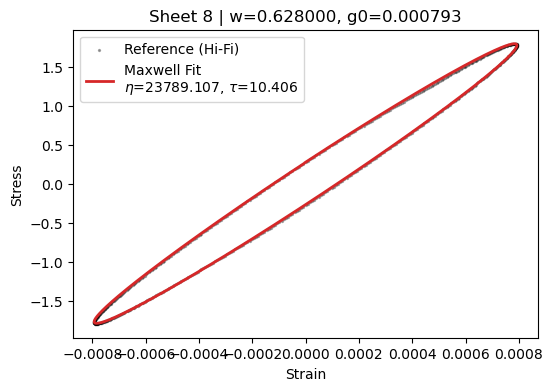

--- Processing Sheet 9: 0.628rad - 0.0026243 ---
0.628rad - 0.0026243
Start Index:  0


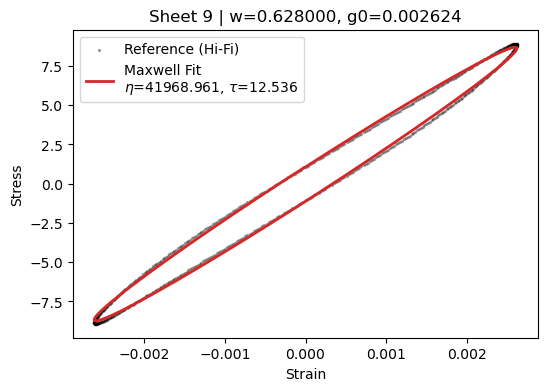

--- Processing Sheet 10: 0.628rad - 0.0072428 ---
0.628rad - 0.0072428
Start Index:  0


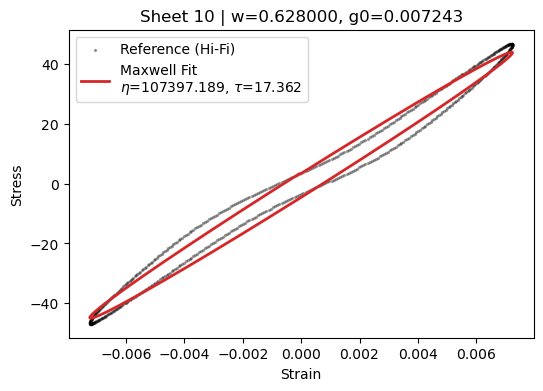

--- Processing Sheet 11: 0.628rad - 0.036871 ---
0.628rad - 0.036871
Start Index:  0


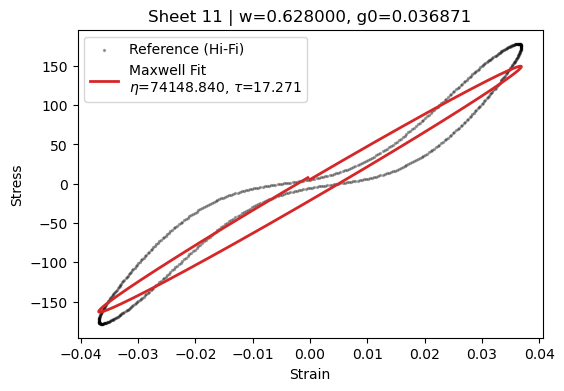

--- Processing Sheet 12: 0.628rad - 7.76e-05 ---
0.628rad - 7.76e-05
Start Index:  0


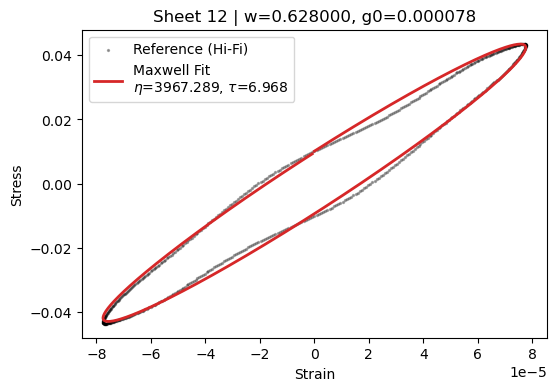

--- Processing Sheet 13: 0.628rad - 0.000234 ---
0.628rad - 0.000234
Start Index:  0


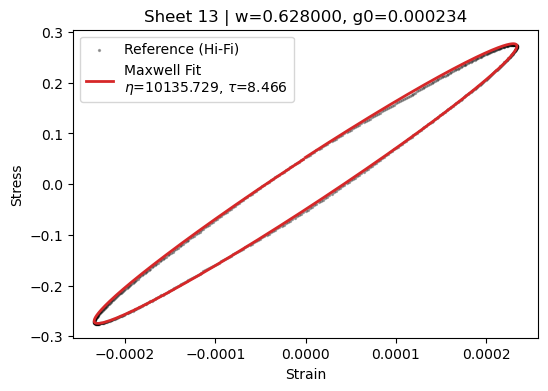

--- Processing Sheet 14: 0.628rad - 0.0008087 ---
0.628rad - 0.0008087
Start Index:  0


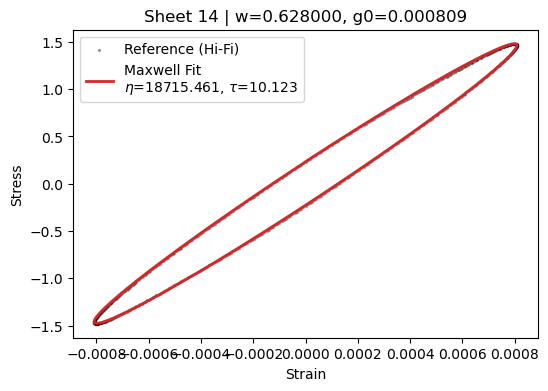

--- Processing Sheet 15: 0.628rad - 0.002616 ---
0.628rad - 0.002616
Start Index:  0


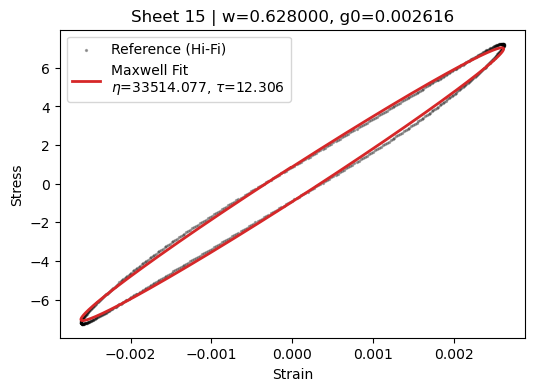

--- Processing Sheet 16: 0.628rad - 0.0069447 ---
0.628rad - 0.0069447
Start Index:  0


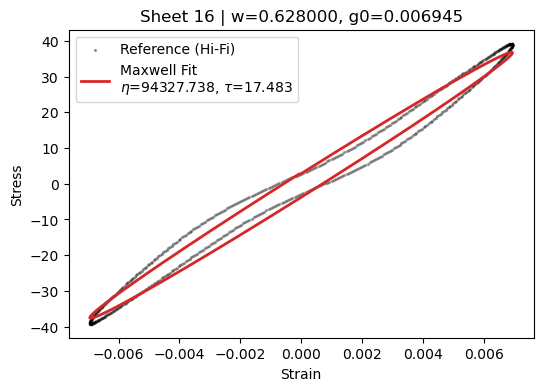

--- Processing Sheet 17: 0.628rad - 0.0303729 ---
0.628rad - 0.0303729
Start Index:  0


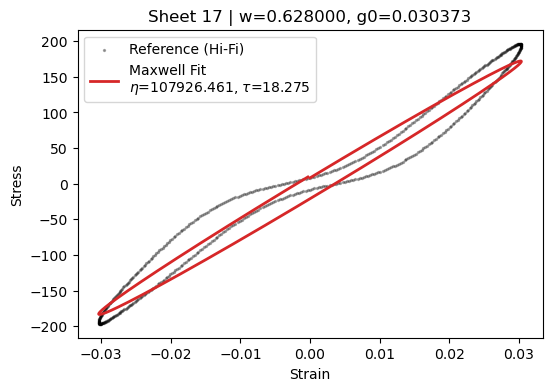

--- Processing Sheet 18: 0.628rad - 6.77e-05 ---
0.628rad - 6.77e-05
Start Index:  0


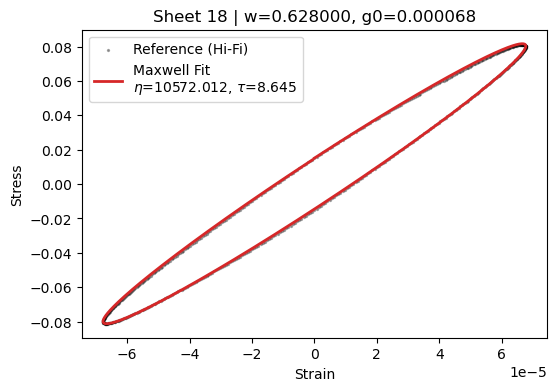

--- Processing Sheet 19: 0.628rad - 0.0002321 ---
0.628rad - 0.0002321
Start Index:  0


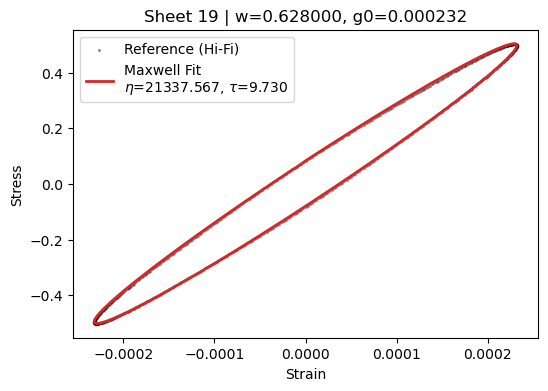

--- Processing Sheet 20: 0.628rad - 0.000835 ---
0.628rad - 0.000835
Start Index:  0


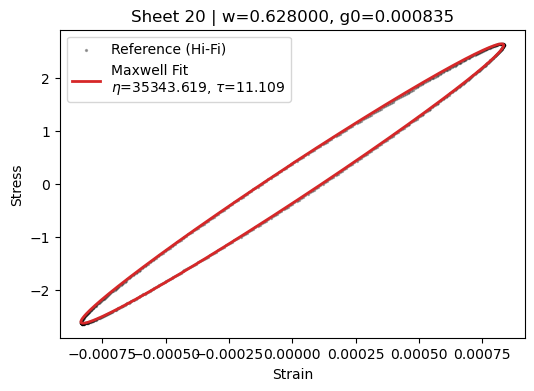

--- Processing Sheet 21: 0.628rad - 0.0027183 ---
0.628rad - 0.0027183
Start Index:  0


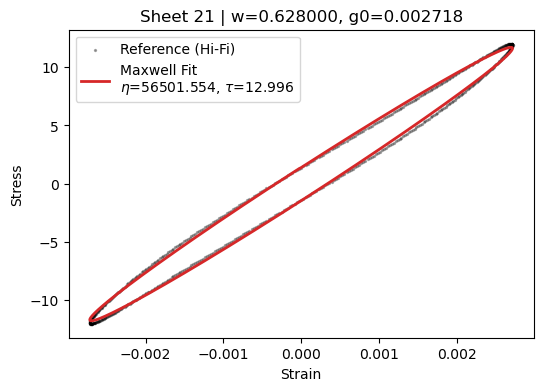

--- Processing Sheet 22: 0.628rad - 0.0079461 ---
0.628rad - 0.0079461
Start Index:  0


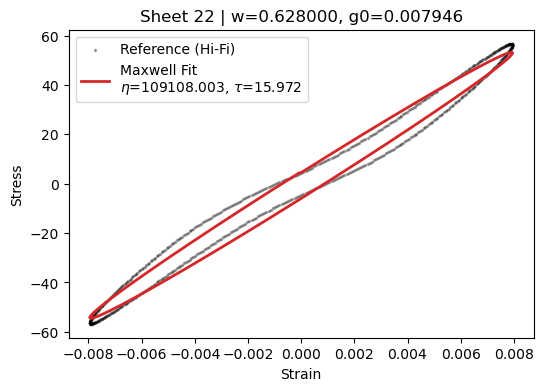

--- Processing Sheet 23: 0.628rad - 7.83e-05 ---
0.628rad - 7.83e-05
Start Index:  0


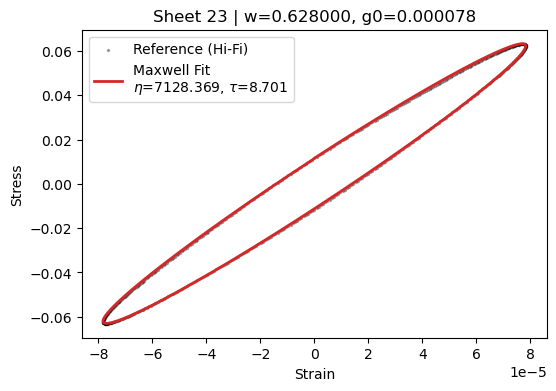

--- Processing Sheet 24: 0.628rad - 0.0002521 ---
0.628rad - 0.0002521
Start Index:  0


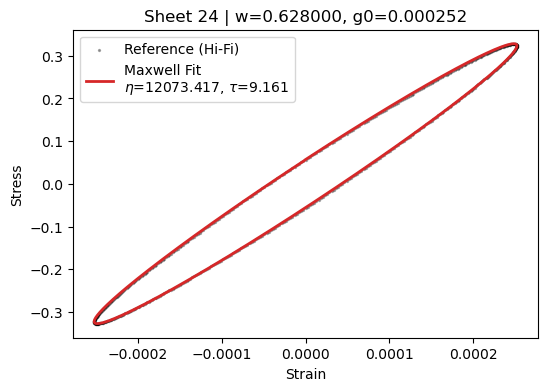

--- Processing Sheet 25: 0.628rad - 0.0008682 ---
0.628rad - 0.0008682
Start Index:  0


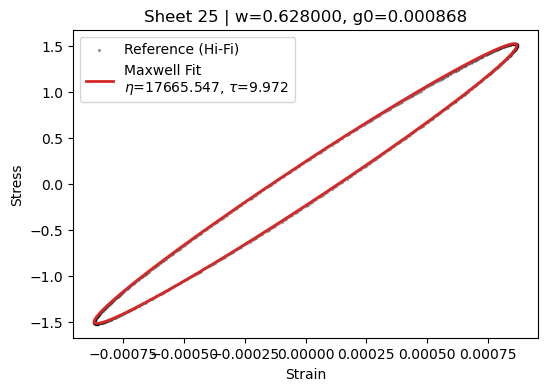

--- Processing Sheet 26: 0.628rad - 0.0027884 ---
0.628rad - 0.0027884
Start Index:  0


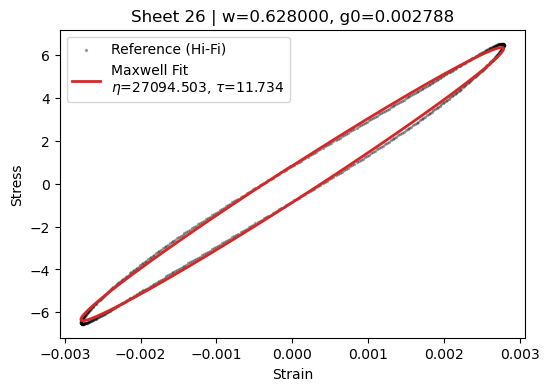

--- Processing Sheet 27: 0.628rad - 0.0075938 ---
0.628rad - 0.0075938
Start Index:  0


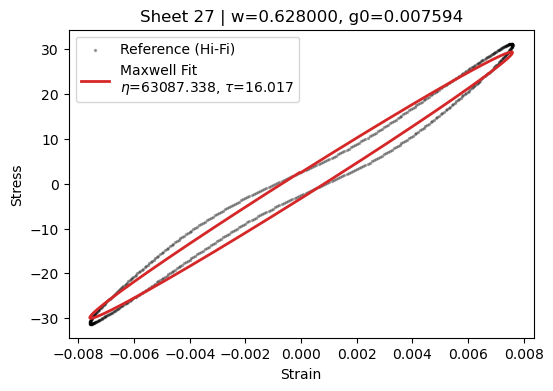

--- Processing Sheet 28: 0.628rad - 0.041893 ---
0.628rad - 0.041893
Start Index:  0


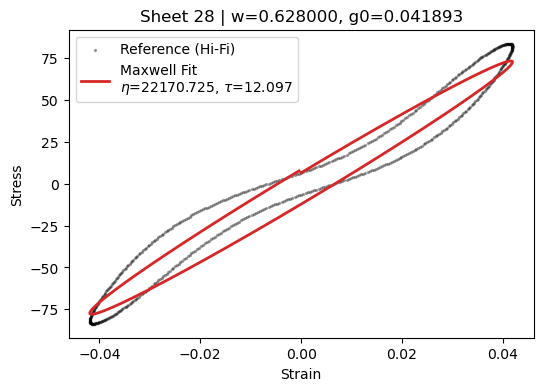


Y_fit (eta, tau):
array([[ 17584.98728135,      9.86737822],
       [ 27972.12420263,     10.30065329],
       [ 40922.70668386,     11.36512972],
       [ 66208.07934177,     13.69804003],
       [163813.03707256,     19.10586723],
       [303958.64553755,     20.37818025],
       [  4710.46421544,      7.47381895],
       [ 12606.1649059 ,      8.85889901],
       [ 23789.10737289,     10.40649169],
       [ 41968.96097935,     12.5362546 ],
       [107397.1893309 ,     17.36200889],
       [ 74148.83981365,     17.27084827],
       [  3967.28883187,      6.96782623],
       [ 10135.72886532,      8.46604747],
       [ 18715.46135995,     10.12285686],
       [ 33514.07658691,     12.30608297],
       [ 94327.7382913 ,     17.48307901],
       [107926.46115725,     18.27505074],
       [ 10572.01188902,      8.64540292],
       [ 21337.56693524,      9.73032462],
       [ 35343.6187251 ,     11.10917081],
       [ 56501.55425136,     12.99567564],
       [109108.00303772,     15.972

In [4]:
# ODE INT

# Initialize lists to store the results from all sheets
Y_fit_list = []
X_fit_list = []
y0_fit_list = []


# Define the ODE function (relies on global g0, omega, which we update in the loop)
def maxwell_ve(y, t, eta, tau, g0, omega, tmax, wmax):
    gdot = g0 * omega * np.cos(omega * t * tmax * wmax)
    dydt = (1.0 / tau) * (eta * gdot - y)
    return dydt


def fit_function(t, eta, tau, y0, g0, omega, tmax, wmax):
    y_pred = odeint(maxwell_ve, y0, t, args=(eta, tau, g0, omega, tmax, wmax))
    return y_pred[:, 0]


# Loop over all sheets
for i in range(len(data)):
    print(f"--- Processing Sheet {i}: {data[i][0]} ---")
    
    # Extract data for this specific sheet
    t_train, g_train, w_train, s_train, st_train, sr_train = extractor(i)
    
    # Normalization settings: ONLY NEEDED FOR MLP Regressor
    Norm = False
    if Norm:
        tmax = max(t_train)
        gmax = max(g_train)
        wmax = max(w_train)
        smax = max(s_train)
        t_train, g_train, w_train, s_train = t_train/tmax, g_train/gmax, w_train/wmax, s_train/smax
    else:
        tmax = 1.
        gmax = 1.
        wmax = 1.
        smax = 1.

    # Get relevant maxwell variables
    assert len(np.unique(g_train)) == 1
    assert len(np.unique(w_train)) == 1
    g0 = np.unique(g_train)[0]
    omega = np.unique(w_train)[0]
    y0 = s_train.iloc[0] if hasattr(s_train, 'iloc') else s_train[0]
    
    # Setup fitting vectors
    t = t_train
    y = s_train
    g = g0 * np.sin(omega * t_train * tmax * wmax)  # Theoretical strain ONLY for plotting, should be fine to use st_train with SPP

    # Wrapper to freeze extra variables
    fit_wrapper = lambda t_val, eta_val, tau_val: fit_function(
        t_val, eta_val, tau_val,
        y0, g0, omega, tmax, wmax
    )

    # Make initial guess and bounds
    stress_amp = (np.max(s_train) - np.min(s_train)) / 2.0
    eta_guess = stress_amp / (g0 * omega)
    tau_guess = 1.0 / omega
    initial_guess = [eta_guess, tau_guess]
    
    # Perform the Fit
    bounds = ([0.0, 0.0], [np.inf, np.inf])
    try:
        fit_params, covariance = curve_fit(fit_wrapper, t, y,
                                           p0=initial_guess,
                                           bounds=bounds,
                                           method='trf',
                                           maxfev=5000)
        eta_fit, tau_fit = fit_params
    except RuntimeError:
        print(f"Fit failed for sheet {i}. Using zeros.")
        eta_fit, tau_fit = 0.0, 0.0

    # Append results
    Y_fit_list.append([eta_fit, tau_fit])   # Y_fit stores [eta, tau]
    X_fit_list.append([omega, g0])  # X_fit stores [omega, g0]
    y0_fit_list.append(y0)  # y0_fit stores the initial stress

    # Plot
    y_predicted = fit_function(t, eta_fit, tau_fit, y0, g0, omega, tmax, wmax)
    
    plt.figure(figsize=(6, 4))
    plt.title(f"Sheet {i} | w={omega:.6f}, g0={g0:.6f}")
    plt.scatter(g, y, label='Reference (Hi-Fi)', s=2, color='k', alpha=0.3)
    plt.plot(g, y_predicted, '-', label=f'Maxwell Fit\n$\eta$={eta_fit:.3f}, $\\tau$={tau_fit:.3f}', linewidth=2, color='tab:red')
    plt.xlabel('Strain')
    plt.ylabel('Stress')
    plt.legend()
    plt.show()

# Convert lists to numpy arrays for the next steps
Y_fit = np.array(Y_fit_list)
X_fit = np.array(X_fit_list)
y0_fit = np.array(y0_fit_list)

print("\nY_fit (eta, tau):")
print(repr(Y_fit))
print("\nX_fit (omega, g0):")
print(repr(X_fit))
print("\ny0_fit (initial stress):")
print(repr(y0_fit))

### Masking Hi-Fi data
Here, and depending on which stress loop we wish to omit from MFNN training, we select from `hf_set`.

In [5]:
# Use train_test_split to create a 20% "masking" set
# 'indices' will allow us to map back to Y_fit and y0_fit easily
indices = np.arange(len(X_fit))
X_all = X_fit
Y_all = Y_fit
y_00_all = y0_fit

# idx_train, idx_test = train_test_split(indices, test_size=0.20, random_state=8)

# X_train = X_fit[idx_train]
# Y_train = Y_fit[idx_train]
# y_00_train  = y0_fit[idx_train]

# X_test = X_fit[idx_test]
# Y_test = Y_fit[idx_test]
# y_00_test  = y0_fit[idx_test]


# print('\nThe masked set(s) are:\n', idx_test)

### Regression of $\tau$ and $\eta$ on $\gamma_0$ and $\omega$

Here, we have several options to select the regression kernel. The output of this cell is the regressed $\tau$ and $\eta$ values for each kernel.

In [6]:
# TODO: Research RegressorChain for multi-output with XGBoost
# QUESTION: Scale inputs as well?
X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all, test_size=0.1, random_state=8)
xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_jobs=1,
    random_state=8,
    tree_method='hist'
)
chain = RegressorChain(estimator=xgb_base, order=[0, 1])
model = TransformedTargetRegressor(
    regressor=chain,
    func=np.log1p, 
    inverse_func=np.expm1
)
param_dist = {
    'regressor__estimator__n_estimators': [200, 300, 500],
    'regressor__estimator__max_depth': [3, 4, 5],
    'regressor__estimator__learning_rate': [0.01, 0.05, 0.1],
    'regressor__estimator__colsample_bytree': [0.6, 0.8, 1.0],
    'regressor__estimator__subsample': [0.6, 0.8, 1.0]
}
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=8
)
print("Tuning RegressorChain...")
search.fit(X_train, Y_train)
best_model = search.best_estimator_
best_model.fit(X_all, Y_all)
xgb_predictions = best_model.predict(X_all)

print(f"Best Parameters: {search.best_params_}")

eta_mse = mean_squared_error(Y_all[:, 0], xgb_predictions[:, 0])
tau_mse = mean_squared_error(Y_all[:, 1], xgb_predictions[:, 1])


poly_regressor = make_pipeline(PolynomialFeatures(degree=2), MultiOutputRegressor(LinearRegression()))
poly_regressor.fit(X_all, Y_all)
poly_predictions = poly_regressor.predict(X_all)

rf_regressor = MultiOutputRegressor(RandomForestRegressor(n_estimators=250, random_state=8))
rf_regressor.fit(X_all, Y_all)
rf_predictions = rf_regressor.predict(X_all)

# scaler_X = StandardScaler()
# X_scaled = scaler_X.fit_transform(X_fit)
# # Define Kernel
# # Constant * RBF (smoothness) + WhiteKernel (noise tolerance)
# kernel = C(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
# gpr_regressor = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
# gpr_regressor.fit(X_scaled, Y_all)
# gpr_predictions = gpr_regressor.predict(X_scaled)

# X_pred_scaled = scaler_X.transform(np.reshape([omega, g0], (1,-1)))   
# log_preds = gpr.predict(X_pred_scaled)
# eta_pred, tau_pred = np.exp(log_preds[0])
# mlp_regressor = MultiOutputRegressor(MLPRegressor(hidden_layer_sizes=(20, 20, 20, 20),
#                                                   max_iter=10000,
#                                                   random_state=4,
#                                                   solver='lbfgs',
#                                                  activation='tanh',
#                                                  alpha=1e-3))
# mlp_regressor.fit(X_train, Y_train)
# mlp_predictions = mlp_regressor.predict(X_train)

print("\nXGBoost Regression Predictions:")
print(xgb_predictions)
print(f"Eta MSE (Corrected): {eta_mse}")
print(f"Tau MSE (Corrected): {tau_mse}")

print("Second-Order Polynomial Regression Predictions:")
print(poly_predictions)
print("Eta MSE: ", mean_squared_error(Y_all[:, 0], poly_predictions[:, 0]))
print("Tau MSE: ", mean_squared_error(Y_all[:, 1], poly_predictions[:, 1]))

print("\nRandom Forest Regression Predictions:")
print(rf_predictions)
print("Eta MSE: ", mean_squared_error(Y_all[:, 0], rf_predictions[:, 0]))
print("Tau MSE: ", mean_squared_error(Y_all[:, 1], rf_predictions[:, 1]))
# print("\nGaussian Process Regression Predictions:")
# print(gpr_predictions)

# print("\nMLP Regression Predictions:")
# print(mlp_predictions)

Tuning RegressorChain...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'regressor__estimator__subsample': 0.6, 'regressor__estimator__n_estimators': 300, 'regressor__estimator__max_depth': 3, 'regressor__estimator__learning_rate': 0.1, 'regressor__estimator__colsample_bytree': 0.6}

XGBoost Regression Predictions:
[[ 17029.44318741      9.37262844]
 [ 26918.63202612     10.15143207]
 [ 38765.22885104     11.45723322]
 [ 60142.80438647     12.94291674]
 [146780.43247652     17.10279215]
 [284186.42860387     20.20967964]
 [  4600.87616072      6.98714151]
 [ 13227.87378163      8.92806004]
 [ 22722.1252889      10.36550353]
 [ 42372.63434051     12.59619977]
 [106857.09426526     17.36336184]
 [ 72845.56984959     16.32116128]
 [  4187.4418738       6.99359392]
 [ 10840.57345742      8.59319315]
 [ 20295.2599632      10.13334626]
 [ 34568.31579066     12.2356743 ]
 [ 94645.74091445     17.44736024]
 [109551.10288093     17.49037626]
 [ 11175.59425721   

### Hi-Fi data extraction and sampling
Since we used the raw Hi-Fi data, we need to extract those shifted Hi-Fi data and use them for MFNN training. Also, the given Hi-Fi data was too dense, and we sample every 40 of them.

In [7]:
hf_set = indices

print(f"Training on {len(hf_set)} samples. Masking {len(indices)} samples.")
print(f"Masked Indices: {indices}")

t_hf_list, g0_hf_list, w_hf_list, g_hf_list, gdot_hf_list, s_hf_list = [], [], [], [], [], []

for i in hf_set:
    t_hf, g0_hf, w_hf, s_hf, st_hf, sr_hf = extractor(i)

    idx = np.arange(0, len(t_hf), 40)
    
    g0_hf_list.append(g0_hf[idx])
    t_hf_list.append(t_hf[idx])
    w_hf_list.append(w_hf[idx])
    
    g_hf_list.append(st_hf[idx])
    gdot_hf_list.append(sr_hf[idx])
    s_hf_list.append(s_hf[idx])


t_hf_sampled = np.concatenate(t_hf_list)
g0_hf_sampled = np.concatenate(g0_hf_list)
w_hf_sampled = np.concatenate(w_hf_list)
g_hf_sampled = np.concatenate(g_hf_list)
gdot_hf_sampled = np.concatenate(gdot_hf_list)
s_hf_sampled = np.concatenate(s_hf_list)

print(f"Final sampled data points: {len(s_hf_sampled)}")

Training on 29 samples. Masking 29 samples.
Masked Indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28]
0.628rad - 7.19e-05
Start Index:  0
0.628rad - 0.0002555
Start Index:  0
0.628rad - 0.0008726
Start Index:  0
0.628rad - 0.0027413
Start Index:  0
0.628rad - 0.0073965
Start Index:  0
0.628rad - 0.0235937
Start Index:  0
0.628rad - 7.46e-05
Start Index:  0
0.628rad - 0.0002212
Start Index:  0
0.628rad - 0.0007927
Start Index:  0
0.628rad - 0.0026243
Start Index:  0
0.628rad - 0.0072428
Start Index:  0
0.628rad - 0.036871
Start Index:  0
0.628rad - 7.76e-05
Start Index:  0
0.628rad - 0.000234
Start Index:  0
0.628rad - 0.0008087
Start Index:  0
0.628rad - 0.002616
Start Index:  0
0.628rad - 0.0069447
Start Index:  0
0.628rad - 0.0303729
Start Index:  0
0.628rad - 6.77e-05
Start Index:  0
0.628rad - 0.0002321
Start Index:  0
0.628rad - 0.000835
Start Index:  0
0.628rad - 0.0027183
Start Index:  0
0.628rad - 0.0079461
Start Index:  0
0.628ra

Almost there. Now, for each set in `lf_set`, which is essentially all the loops, we call the `fit_function()` function, which predicts the linear VE stress response as a function of `t_pred`, `eta_pred`, and `tau_pred`. We then append every variable to an empty vector, and call that our Lo-Fi data. Keeping an eye on the top image as reference can also help. :)

0.628rad - 7.19e-05
Start Index:  0


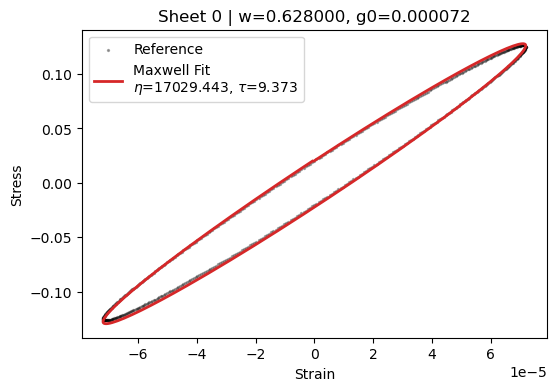

0.628rad - 0.0002555
Start Index:  0


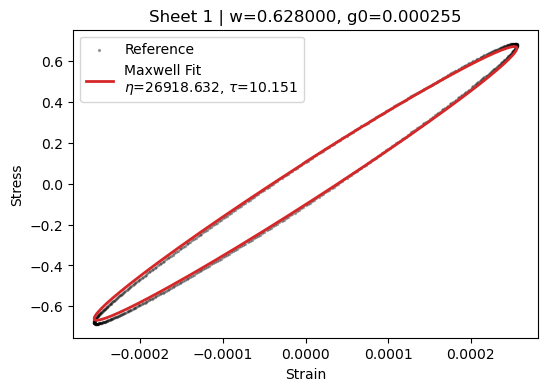

0.628rad - 0.0008726
Start Index:  0


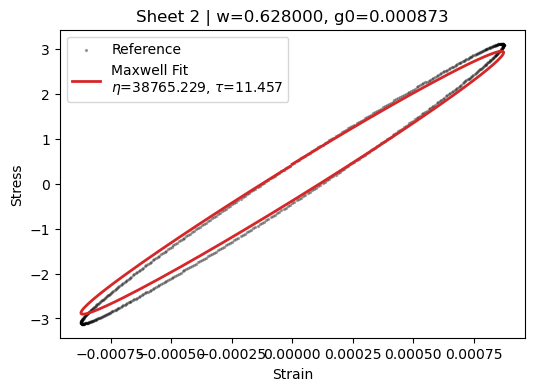

0.628rad - 0.0027413
Start Index:  0


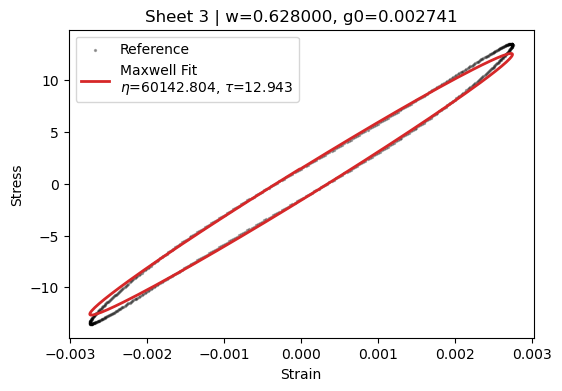

0.628rad - 0.0073965
Start Index:  0


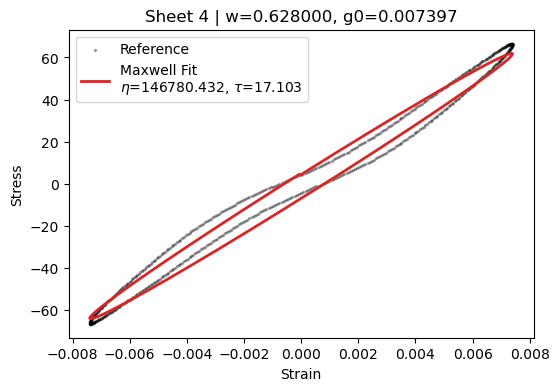

0.628rad - 0.0235937
Start Index:  0


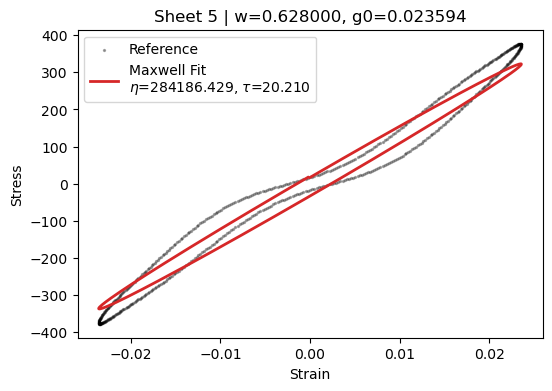

0.628rad - 7.46e-05
Start Index:  0


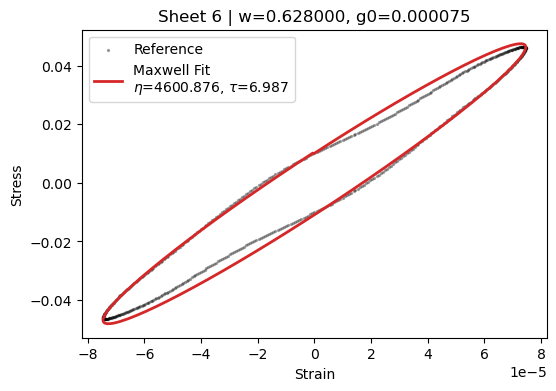

0.628rad - 0.0002212
Start Index:  0


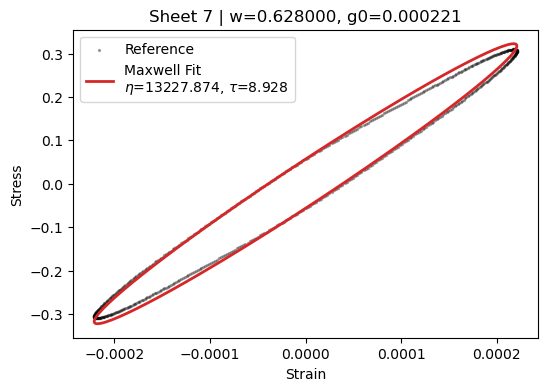

0.628rad - 0.0007927
Start Index:  0


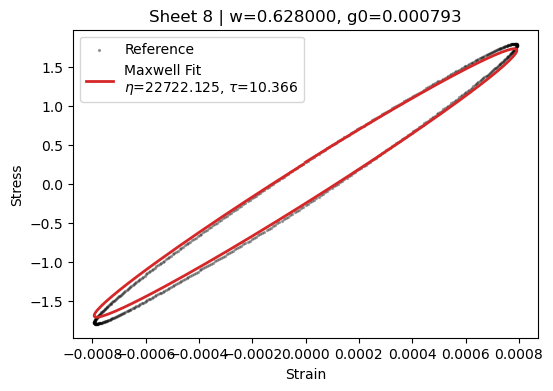

0.628rad - 0.0026243
Start Index:  0


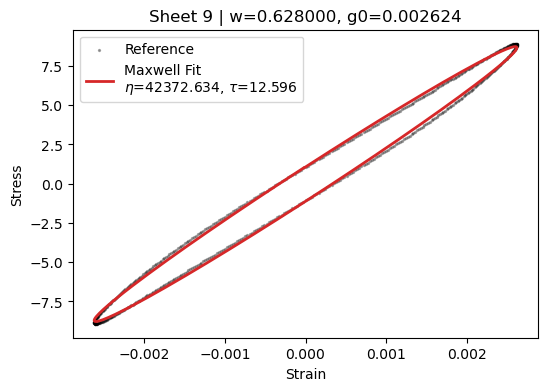

0.628rad - 0.0072428
Start Index:  0


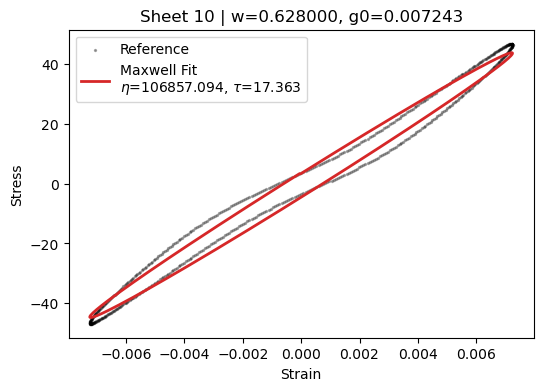

0.628rad - 0.036871
Start Index:  0


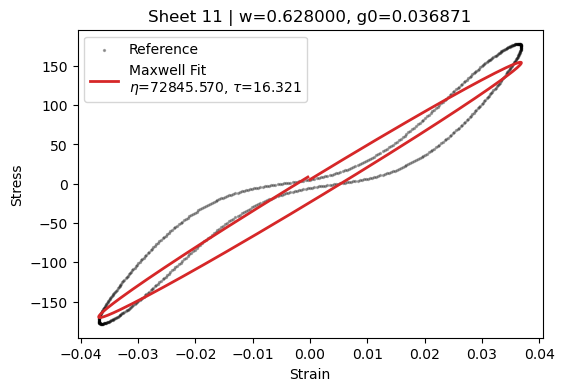

0.628rad - 7.76e-05
Start Index:  0


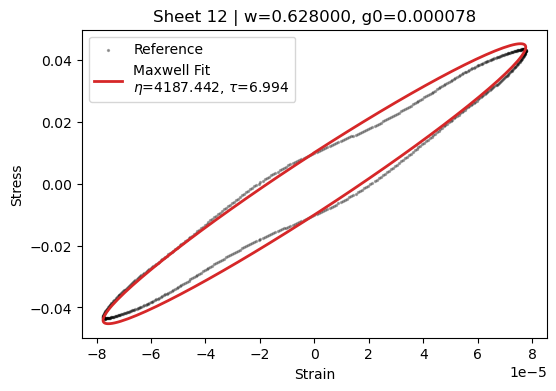

0.628rad - 0.000234
Start Index:  0


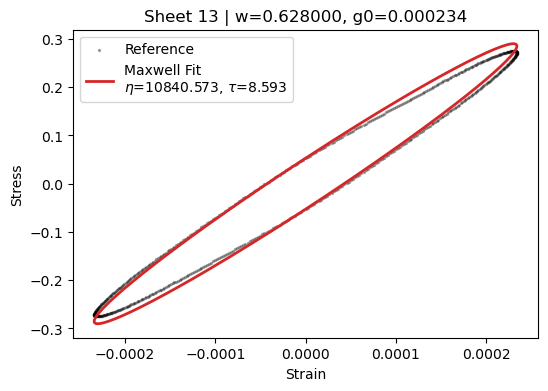

0.628rad - 0.0008087
Start Index:  0


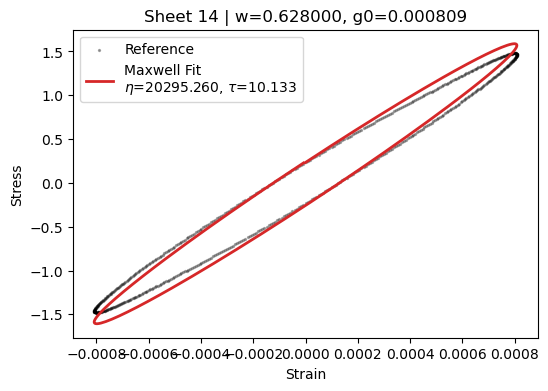

0.628rad - 0.002616
Start Index:  0


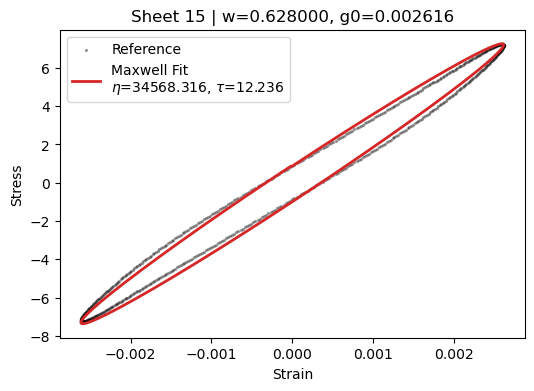

0.628rad - 0.0069447
Start Index:  0


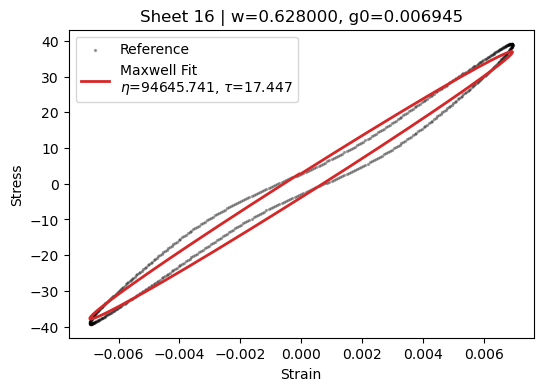

0.628rad - 0.0303729
Start Index:  0


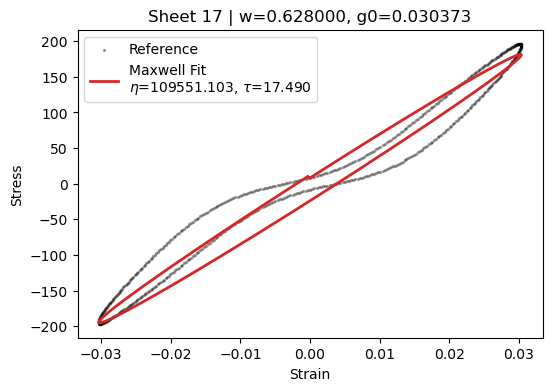

0.628rad - 6.77e-05
Start Index:  0


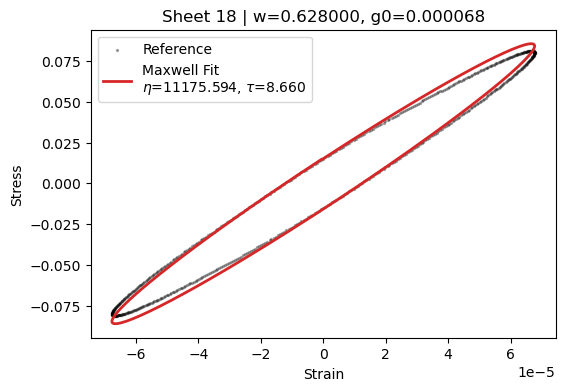

0.628rad - 0.0002321
Start Index:  0


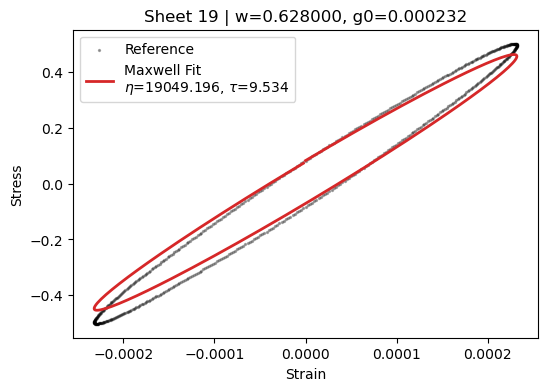

0.628rad - 0.000835
Start Index:  0


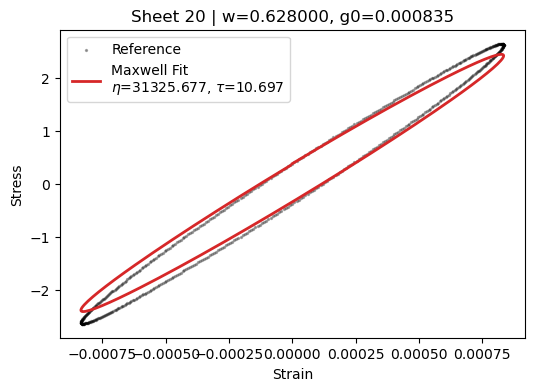

0.628rad - 0.0027183
Start Index:  0


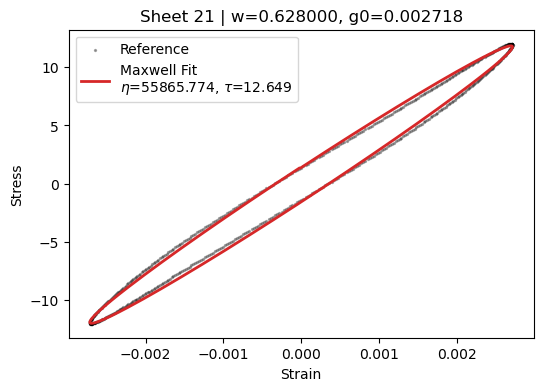

0.628rad - 0.0079461
Start Index:  0


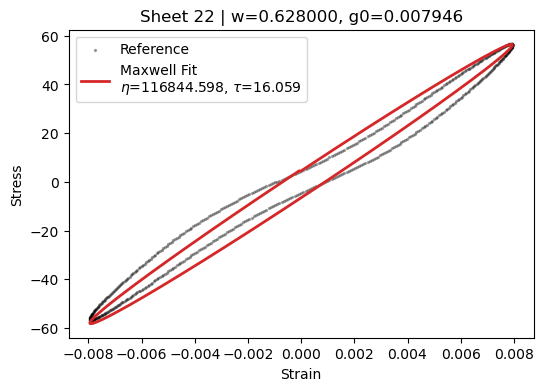

0.628rad - 7.83e-05
Start Index:  0


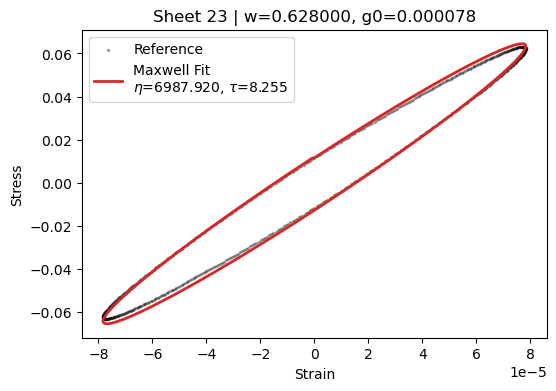

0.628rad - 0.0002521
Start Index:  0


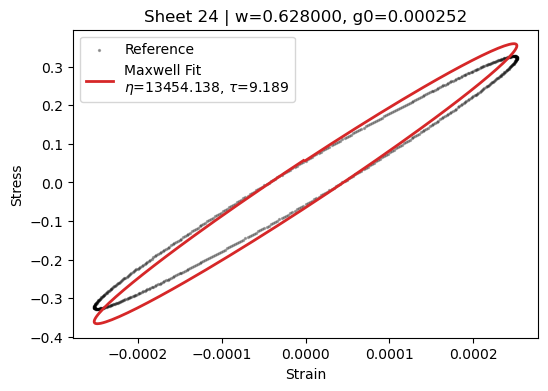

0.628rad - 0.0008682
Start Index:  0


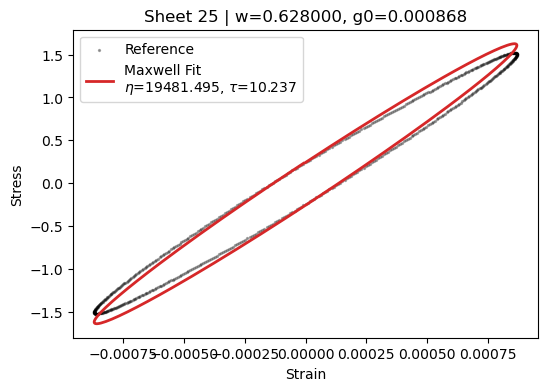

0.628rad - 0.0027884
Start Index:  0


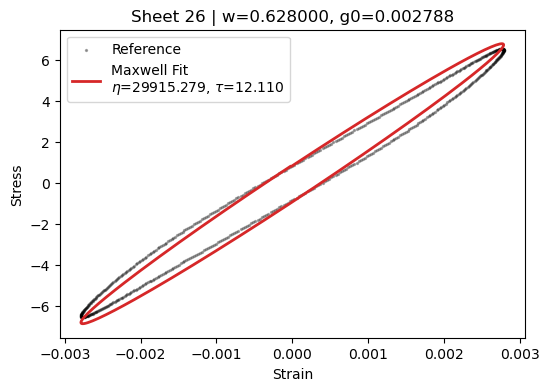

0.628rad - 0.0075938
Start Index:  0


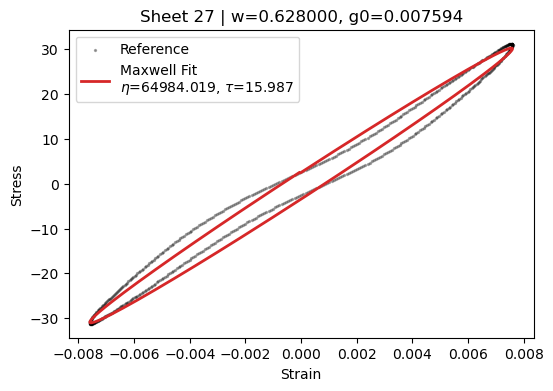

0.628rad - 0.041893
Start Index:  0


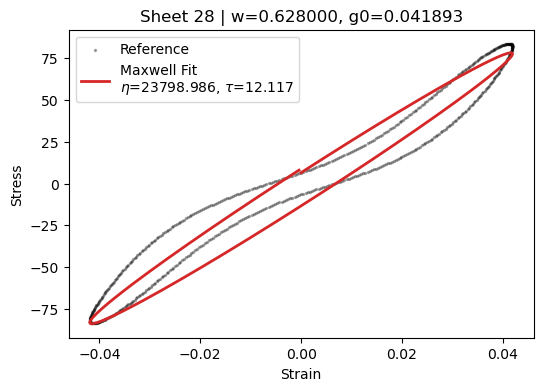

In [8]:
y000 = y0_fit
g00 = X_fit[:,1]
omega0 = X_fit[:,0]
lf_set = indices
N_exp = int(10.*len(s_hf_sampled)/len(lf_set))  # Desired ratio of LF to HF data points

# Use lists, np.append is slow  
t_lf_list, g0_lf_list, w_lf_list, g_lf_list, gdot_lf_list, s_lf_list = [], [], [], [], [], []

for i in lf_set:
    t_test, g0_test, w_test, s_test, st_test, sr_test = extractor(i)

    omega = omega0[i]
    g0 = g00[i]
    y0 = y000[i]
    
    X_pred = np.reshape([omega, g0], (1,-1))
    eta_pred, tau_pred = best_model.predict(X_pred)[0]

    t_pred = np.linspace(min(t_test), max(t_test), N_exp)
    Y_pred = fit_function(t_pred, eta_pred, tau_pred, y0, g0, omega, tmax=1, wmax=1)
    
    g_pred = g0 * np.sin(omega * t_pred)
    gdot_pred = g0*omega*np.cos(omega * t_pred)
    
    #LF generation
    g0_lf_list.extend(g0 * np.ones(N_exp))
    t_lf_list.extend(t_pred)
    w_lf_list.extend(omega * np.ones(N_exp))
    
    g_lf_list.extend(g_pred)
    gdot_lf_list.extend(gdot_pred)
    s_lf_list.extend(Y_pred)

    plt.figure(figsize=(6, 4))
    plt.title(f"Sheet {i} | w={omega:.6f}, g0={g0:.6f}")
    plt.scatter(st_test, s_test, label='Reference', s=2, color='k', alpha=0.3)
    plt.plot(g_pred, Y_pred, label=f'Maxwell Fit\n$\eta$={eta_pred:.3f}, $\\tau$={tau_pred:.3f}', linewidth=2, color='tab:red')
    plt.xlabel('Strain')
    plt.ylabel('Stress')
    plt.legend()
    plt.show()


### Exporting the Lo-Fi and Hi-Fi SAOS data
As mentioned above, and due to the time shift, the Hi-Fi data is also generated here based on the raw Hi-Fi data.

In [9]:
df_LF_raw = np.column_stack([g0_lf_list, t_lf_list,
                             w_lf_list, g_lf_list,
                             gdot_lf_list, s_lf_list])
df_LF = pd.DataFrame(df_LF_raw, columns = ['G0','Time', 'AngFreq', 'Strain', 'StrainRate', 'Stress'])
df_LF.to_excel("Data_LF_SAOS.xlsx", index=False)
df_HF_raw = np.column_stack([g0_hf_sampled, t_hf_sampled,
                             w_hf_sampled, g_hf_sampled,
                             gdot_hf_sampled, s_hf_sampled])
df_HF = pd.DataFrame(df_HF_raw, columns = ['G0','Time', 'AngFreq', 'Strain', 'StrainRate', 'Stress'])
df_HF.to_excel("Data_HF_SAOS.xlsx", index=False)